In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


In [6]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_20720\1209351260.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


# ARIMA Models

In [8]:
arima_models = auto_arima(data["windspeed"], trace= True, suppress_warnings= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=20.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=125994.010, Time=0.36 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=124297.083, Time=0.77 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=123856.141, Time=1.60 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=125992.010, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=123023.577, Time=5.42 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=9.94 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=10.85 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=123668.047, Time=2.17 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=123978.256, Time=1.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=123021.577, Time=2.00 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=123854.141, Time=0.70 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=124295.083, Time=0.39 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=inf, Time=3.53 sec
 ARIMA(1,1,2)(0,0,0)[0]        

# Split Data

In [9]:
x_train = data["windspeed"][: -168]
x_test = data["windspeed"][-168: ]
x_train.shape, x_test.shape

((21815,), (168,))

In [10]:
model = ARIMA(x_test, order = (1, 1, 1))
model_fit = model.fit()
model_fit.summary()

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              windspeed   No. Observations:                  168
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -470.287
Date:                Sat, 20 Jul 2024   AIC                            946.574
Time:                        11:59:03   BIC                            955.928
Sample:                    06-28-2024   HQIC                           950.371
                         - 07-04-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8116      0.049     16.706      0.000       0.716       0.907
ma.L1         -0.9905      0.029    -34.103      0.000      -1.047      -0.934
sigma2        16.1802      1.557     10.390      0.000      13.128      19.232
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 7.12
Prob(Q):                              0.83   Prob(JB):                         0.03
Heteroskedasticity (H):               1.24   Skew:                             0.37
Prob(H) (two-sided):                  0.43   Kurtosis:                         3.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
start_0 = len(x_train)
end_0 = start_0 + len(x_test) - 1
predictions_0 = model_fit.predict(start= start_0, end= end_0, typ='levels')
predictions_0.index = x_test.index

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


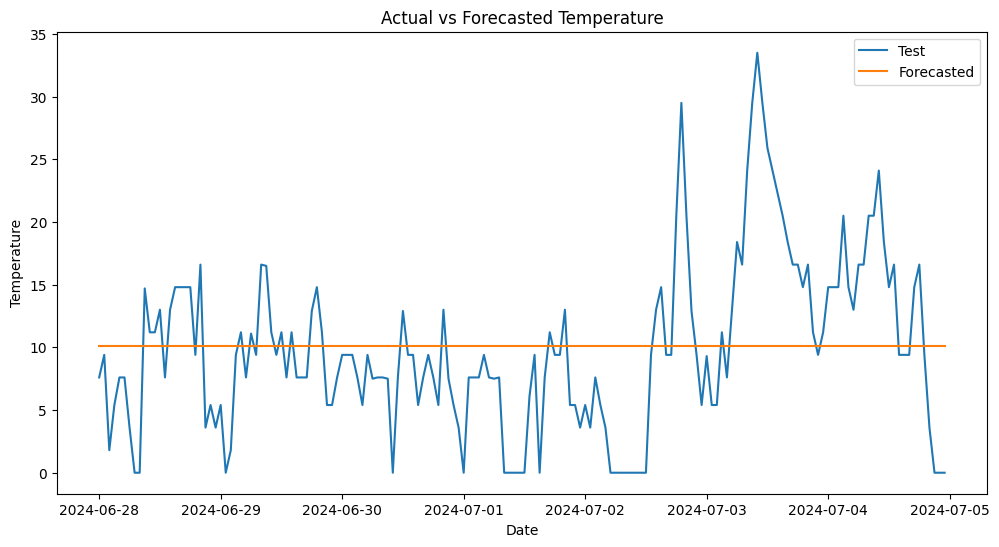

In [12]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions_0, label='Forecasted')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# SARIMA Model

In [13]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(x_train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -15.634363055664604
p-value: 1.6701397630434255e-28


In [14]:
model_sarima = SARIMAX(x_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          windspeed   No. Observations:                21815
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -60764.088
Date:                            Sat, 20 Jul 2024   AIC                         121538.175
Time:                                    12:01:55   BIC                         121578.121
Sample:                                         0   HQIC                        121551.190
                                          - 21815                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5753      0.007     81.074      0.000       0.561       0.589
ma.L1         -0.8979      0.004   

### seasonal_order(1, 1, 1, 24) $\rightarrow$ 99.3939%
### seasonal_order(1, 1, 2, 24) $\rightarrow$ 99.3934%
### seasonal_order(2, 1, 2, 24) $\rightarrow$ 99.3943%


In [15]:
x_train.index = pd.to_datetime(x_train.index)
x_test.index = pd.to_datetime(x_test.index)

In [16]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test))
predictions = forecast.predicted_mean
predictions.index = x_test.index

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


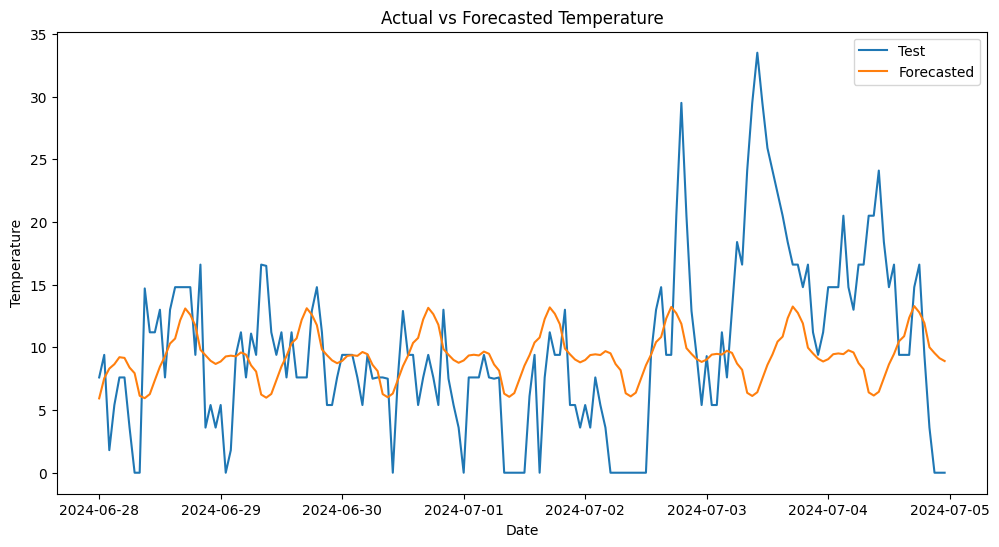

In [17]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions, label='Forecasted')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [23]:
mse = mean_squared_error(x_test, predictions)
tss = ((x_test - x_test.mean()) ** 2).sum()
r_squared = 1 - (mse / tss)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 99.39391775% of total variability 
 Root Mean Squared Error =  6.812166564268985
